Calculating symbol-attribute/value MI scores with the function "symbol_frequency_mi",
taken from zero_shot repository by Kristina Kobrock 

https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py

The function can be found in analysis_from_interaction.py. It excludes the last symbol of each message (EOS symbol "0") from consideration, but doesn't exclude symbol "0" if it appears earlier in the message, or any symbols after the first "0".

For calculating MI scores for the datasets created with a message length cost, a new function was used "symbol_frequency_MI_new": a modified version of "symbol_frequency_MI", which ignores the first "0" symbol in a message and all symbols after that. This function can also be found in analysis_from_interaction.py.

In [16]:
from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import error_analysis
from collections import Counter
from utils.analysis_from_interaction import *
import itertools
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
plt.style.use('default')
import random
from seaborn.algorithms import bootstrap
import pickle
from utils.analysis_from_interaction import *
from egg.core.language_analysis import Disent
from language_analysis_local import TopographicSimilarityConceptLevel, encode_target_concepts_for_topsim
import os
import numpy as np

D(3,3) Split, No length cost, Vocab size 13,

 5 runs

HDA - highly discriminative attribute

HDA Indices in each run: 1, 0, 2, 1, 0

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # always context aware
shared_context = True
split_by_attribute = True
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [ ]:
# code taken from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/analysis_zero_shot_qualitative.ipynb
# and modified to return average MI scores and standard deviations across all attributes (and runs)
# function "symbol_frequency_MI" is in "analysis_from_interaction.py", copied from zero_shot repository:
# from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py

# additionally, this function has been modified to compute average MI scores and standard deviations across all attributes (and runs)
vocab_size = 13
# store average MI scores per run (to compute overall mean and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    dataset_label = f"D{tuple(d)}" if not isinstance(d, str) else d
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")



(3,3)
training, run  0 :  {'00': 3, '01': 7, '02': 9, '10': 8, '11': 5, '12': 1, '20': 12, '21': 4, '22': 2} {'00': 0.3181064938760893, '01': 0.15289335020088296, '02': 0.37738184618443926, '10': 0.33282841190729345, '11': 0.27367262131923537, '12': 0.2710903237808576, '20': 0.2913512689423247, '21': 0.14278687510580898, '22': 0.22731458102837537}
testing, run  0 :  {'00': 3, '01': 4, '02': 9, '10': 8, '11': 5, '12': 1, '20': 12, '21': 4, '22': 2} {'00': 0.20050441044665024, '01': 0.17506846785589844, '02': 0.2174362770836741, '10': 0.5564299848137939, '11': 0.43271713881129203, '12': 0.39344063758399467, '20': 0.17396540556261852, '21': 0.13064671745059064, '22': 0.08727458681009047}
Run 0 - Train MI: 0.265 ± 0.074
Run 0 - Test  MI: 0.263 ± 0.150
training, run  1 :  {'00': 10, '01': 4, '02': 8, '10': 11, '11': 5, '12': 2, '20': 6, '21': 9, '22': 11} {'00': 0.4726507752953024, '01': 0.4414629177811777, '02': 0.3681311148453955, '10': 0.10163156542946376, '11': 0.10666017462796, '12': 0

In [ ]:
# code to automatically generate LaTeX tables for MI scores
from pathlib import Path

def _parse_key_for_sort(k):
    """Sort keys like '00','01','02','10','11','12','20', ... in natural numeric order."""
    try:
        return tuple(int(c) for c in k)
    except Exception:
        return (k,)

def _attr_index_from_key(k):
    """First digit of the key (attribute index). Ex: '20' -> 2."""
    try:
        return int(str(k)[0])
    except Exception:
        return None

# to highlight columns with symbols associated with highly discriminative attribute
def _colspec_highlighted(keys, highlight_index):
    """
    Build a column spec that colors columns yellow when the column key's attribute index
    equals 'highlight_index'. First column is the row label column.
    """
    spec = ["l"]  # first column: left-aligned label column
    for k in keys:
        idx = _attr_index_from_key(k)
        if idx is not None and highlight_index is not None and idx == highlight_index:
            spec.append(">{\\columncolor{yellow!20}}c")   # highlighted column
        else:
            spec.append("c")
    return "|" + "|".join(spec) + "|"

def _row(cells, header=False, bold_all=False):
    """
    Generic row builder. If header=True, makes entire header bold.
    If bold_all=True, makes all data cells (not the first label cell) bold.
    """
    if header:
        cells = [f"\\textbf{{{c}}}" for c in cells]
    elif bold_all:
        # Keep the stub (first cell) as-is; bold the rest
        if cells:
            head = cells[0]
            rest = [f"\\textbf{{{c}}}" for c in cells[1:]]
            cells = [head] + rest
    return " " + " & ".join(cells) + " \\\\ \\hline"

def make_mi_table_latex(dataset_label, run_idx, train_symbols, train_mi, test_symbols, test_mi,
                        highlight_index=None):
    """
    Build a LaTeX table with 5 rows:
      header ('00', '01', etc), symbols train (bold), MI train, symbols test (bold), MI test.
    Columns are the sorted keys (00, 01, 02, 10, 11, 12, ...).
    Columns whose attribute index == highlight_index are colored yellow (highly discriminative attribute).
    """
    # Collect & sort all keys encountered in any of the 4 dicts
    keys = sorted(set(train_symbols) | set(train_mi) | set(test_symbols) | set(test_mi), key=_parse_key_for_sort)

    header = [""] + keys
    r_sym_tr = ["symbols train"] + [str(train_symbols.get(k, "")) for k in keys]
    r_mi_tr  = ["MI train"]      + [f"{train_mi.get(k, float('nan')):.2f}" if k in train_mi else "" for k in keys]
    r_sym_te = ["symbols test"]  + [str(test_symbols.get(k, "")) for k in keys]
    r_mi_te  = ["MI test"]       + [f"{test_mi.get(k, float('nan')):.2f}" if k in test_mi else "" for k in keys]

    colspec = _colspec_highlighted(keys, highlight_index)

    lines = []
    lines.append("\\begin{table}[h!]")
    lines.append("\\small")  # helps wide tables fit
    lines.append(f"\\caption{{{dataset_label} Run {run_idx}}}")
    lines.append(f"\\begin{{tabular}}{{{colspec}}}")
    lines.append("\\hline")
    lines.append(_row(header, header=True))
    lines.append(_row(r_sym_tr, bold_all=True))  # bold symbols (train)
    lines.append(_row(r_mi_tr))
    lines.append(_row(r_sym_te, bold_all=True))  # bold symbols (test)
    lines.append(_row(r_mi_te))
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)

def write_table_file(out_dir, dataset_label, run_idx, latex_str):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    safe_ds = dataset_label.replace("(", "").replace(")", "").replace(",", "_").replace(" ", "")
    fname = f"{safe_ds}_run{run_idx}.tex"
    (out_dir / fname).write_text(latex_str)
    return str(out_dir / fname)

In [ ]:
# code taken from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/analysis_zero_shot_qualitative.ipynb
# and modified to generate LaTeX tables
# function "symbol_frequency_MI" is in "analysis_from_interaction.py", copied from zero_shot repository
# from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py
highlight_index_map = {"(3,3)": [1, 0, 2, 1, 0]} # indices of highly discriminative attribute per run
# additionally, this function has been modified to compute average MI scores
vocab_size = 13
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    dataset_label = f"D{tuple(d)}" if not isinstance(d, str) else d
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        #print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

         # pick highlight index for this run (or None if not provided)
        hl = None
        if dataset_label in highlight_index_map and run < len(highlight_index_map[dataset_label]):
            hl = highlight_index_map[dataset_label][run]

        latex_block = make_mi_table_latex(
        dataset_label=dataset_label,
        run_idx=run,
        train_symbols=favorite_symbol,
        train_mi=mutual_information,
        test_symbols=favorite_symbol_test,
        test_mi=mutual_information_test,
        highlight_index=hl,  # <-- per-run highlight
        )
        print(latex_block)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        #print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        #print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

#print("\n=== Overall Results Across All Runs ===")
#print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
#print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,3)
\begin{table}[h!]
\small
\caption{(3,3) Run 0}
\begin{tabular}{|l|c|c|c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|c|c|c|}
\hline
 \textbf{} & \textbf{00} & \textbf{01} & \textbf{02} & \textbf{10} & \textbf{11} & \textbf{12} & \textbf{20} & \textbf{21} & \textbf{22} \\ \hline
 symbols train & \textbf{3} & \textbf{7} & \textbf{9} & \textbf{8} & \textbf{5} & \textbf{1} & \textbf{12} & \textbf{4} & \textbf{2} \\ \hline
 MI train & 0.32 & 0.15 & 0.38 & 0.33 & 0.27 & 0.27 & 0.29 & 0.14 & 0.23 \\ \hline
 symbols test & \textbf{3} & \textbf{4} & \textbf{9} & \textbf{8} & \textbf{5} & \textbf{1} & \textbf{12} & \textbf{4} & \textbf{2} \\ \hline
 MI test & 0.20 & 0.18 & 0.22 & 0.56 & 0.43 & 0.39 & 0.17 & 0.13 & 0.09 \\ \hline
\end{tabular}
\end{table}
\begin{table}[h!]
\small
\caption{(3,3) Run 1}
\begin{tabular}{|l|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|c|c|c|c|c|c|}
\hline
 \textbf{} & \textbf{00} & \t

D(3,3) No split (shared_context), No Length cost, vocab 13

5 runs

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 5
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [13]:
vocab_size = 13
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,3)
training, run  0 :  {'00': 9, '01': 2, '02': 5, '10': 1, '11': 10, '12': 11, '20': 3, '21': 7, '22': 4} {'00': 0.31616787823907655, '01': 0.23000659770393794, '02': 0.26337365983135724, '10': 0.23405958348236072, '11': 0.4591621056153185, '12': 0.19652860413473833, '20': 0.5293401856288431, '21': 0.5430511007426957, '22': 0.589212620449909}
testing, run  0 :  {'00': 9, '01': 2, '02': 5, '10': 1, '11': 10, '12': 11, '20': 3, '21': 7, '22': 4} {'00': 0.16895480599338378, '01': 0.22033194782797816, '02': 0.2273057028495956, '10': 0.3935328552103148, '11': 0.535260208100822, '12': 0.17455139025671776, '20': 0.40517943815331947, '21': 0.6736593578256416, '22': 0.5089301551179138}
Run 0 - Train MI: 0.373 ± 0.147
Run 0 - Test  MI: 0.368 ± 0.171
training, run  1 :  {'00': 6, '01': 10, '02': 8, '10': 7, '11': 9, '12': 12, '20': 11, '21': 4, '22': 2} {'00': 0.15616815752119076, '01': 0.19611497318186413, '02': 0.17553772264290435, '10': 0.44800191890807123, '11': 0.5014424681679138, '12': 

D(3,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 0, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [16]:
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,4)
training, run  0 :  {'00': 14, '01': 10, '02': 6, '03': 8, '10': 5, '11': 8, '12': 7, '13': 15, '20': 12, '21': 13, '22': 4, '23': 1} {'00': 0.4891020545829364, '01': 0.24263431671580146, '02': 0.4171260768162863, '03': 0.19129257755132195, '10': 0.3057383597106184, '11': 0.10759910320885133, '12': 0.2709151418017866, '13': 0.28139536962992645, '20': 0.3260749112720777, '21': 0.28139536962992645, '22': 0.30645865068063916, '23': 0.13337978105426437}
testing, run  0 :  {'00': 14, '01': 10, '02': 6, '03': 1, '10': 5, '11': 8, '12': 7, '13': 15, '20': 12, '21': 13, '22': 4, '23': 10} {'00': 0.6784097436398828, '01': 0.2548750060157892, '02': 0.6604188946217807, '03': 0.1816819439502119, '10': 0.2663785524167468, '11': 0.15506460878761905, '12': 0.14216137766328069, '13': 0.30612585919784835, '20': 0.21624018902512707, '21': 0.26765659957930377, '22': 0.24754664771859838, '23': 0.09844760749555025}
Run 0 - Train MI: 0.279 ± 0.103
Run 0 - Test  MI: 0.290 ± 0.179
training, run  1 :  {'

In [ ]:
# code taken from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/analysis_zero_shot_qualitative.ipynb
# and modified to generate LaTeX tables
# function "symbol_frequency_MI" is in "analysis_from_interaction.py", copied from zero_shot repository
# from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py
highlight_index_map = {"(3,4)": [0, 0]} # indices of highly discriminative attribute per run
# additionally, this function has been modified to compute average MI scores
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    dataset_label = f"D{tuple(d)}" if not isinstance(d, str) else d
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        #print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

         # pick highlight index for this run (or None if not provided)
        hl = None
        if dataset_label in highlight_index_map and run < len(highlight_index_map[dataset_label]):
            hl = highlight_index_map[dataset_label][run]

        latex_block = make_mi_table_latex(
        dataset_label=dataset_label,
        run_idx=run,
        train_symbols=favorite_symbol,
        train_mi=mutual_information,
        test_symbols=favorite_symbol_test,
        test_mi=mutual_information_test,
        highlight_index=hl,  # <-- per-run highlight
        )
        print(latex_block)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        #print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        #print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

#print("\n=== Overall Results Across All Runs ===")
#print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
#print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,4)
\begin{table}[h!]
\small
\caption{(3,4) Run 0}
\begin{tabular}{|l|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|c|c|c|c|c|c|c|c|}
\hline
 \textbf{} & \textbf{00} & \textbf{01} & \textbf{02} & \textbf{03} & \textbf{10} & \textbf{11} & \textbf{12} & \textbf{13} & \textbf{20} & \textbf{21} & \textbf{22} & \textbf{23} \\ \hline
 symbols train & \textbf{14} & \textbf{10} & \textbf{6} & \textbf{8} & \textbf{5} & \textbf{8} & \textbf{7} & \textbf{15} & \textbf{12} & \textbf{13} & \textbf{4} & \textbf{1} \\ \hline
 MI train & 0.49 & 0.24 & 0.42 & 0.19 & 0.31 & 0.11 & 0.27 & 0.28 & 0.33 & 0.28 & 0.31 & 0.13 \\ \hline
 symbols test & \textbf{14} & \textbf{10} & \textbf{6} & \textbf{1} & \textbf{5} & \textbf{8} & \textbf{7} & \textbf{15} & \textbf{12} & \textbf{13} & \textbf{4} & \textbf{10} \\ \hline
 MI test & 0.68 & 0.25 & 0.66 & 0.18 & 0.27 & 0.16 & 0.14 & 0.31 & 0.22 & 0.27 & 0.25 & 0.10 \\ \hline
\end{tabular}
\end{tabl

D(3,4) No split (shared_context), No Length cost, vocab 16

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [18]:
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,4)
training, run  0 :  {'00': 10, '01': 6, '02': 14, '03': 8, '10': 0, '11': 5, '12': 1, '13': 12, '20': 13, '21': 11, '22': 2, '23': 3} {'00': 0.4796414203713043, '01': 0.5258090094053075, '02': 0.35052598789882977, '03': 0.6019977452940317, '10': 0.309640117213754, '11': 0.36362061884798397, '12': 0.4208110350804333, '13': 0.3153792719132741, '20': 0.15744663842825346, '21': 0.06995279326518783, '22': 0.24547095364626084, '23': 0.18226442375700913}
testing, run  0 :  {'00': 1, '01': 6, '02': 14, '03': 8, '10': 0, '11': 5, '12': 1, '13': 12, '20': 13, '21': 11, '22': 2, '23': 3} {'00': 0.18144378550226034, '01': 0.4624474588355428, '02': 0.3519403056202877, '03': 0.7040914178212493, '10': 0.5228049225779842, '11': 0.3059743340050847, '12': 0.5670965459836298, '13': 0.2986688252919084, '20': 0.32089183159043955, '21': 0.13393753131655764, '22': 0.1725879052522267, '23': 0.17977385184218272}
Run 0 - Train MI: 0.335 ± 0.150
Run 0 - Test  MI: 0.350 ± 0.172
training, run  1 :  {'00': 12

D(4,4) Split, No Length cost, vocab 16

2 runs

HDA indices in each run: 3, 2

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [20]:
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(4,4)
training, run  0 :  {'00': 12, '01': 13, '02': 14, '03': 10, '10': 10, '11': 12, '12': 11, '13': 14, '20': 5, '21': 15, '22': 3, '23': 12, '30': 2, '31': 9, '32': 3, '33': 6} {'00': 0.06293291720681368, '01': 0.2516757260469538, '02': 0.09693151374449893, '03': 0.13661326278521477, '10': 0.09311508212030191, '11': 0.106854936731494, '12': 0.042126686470685105, '13': 0.09564819021695052, '20': 0.2910445922648997, '21': 0.08671691244450211, '22': 0.11833888353678491, '23': 0.05175316544681576, '30': 0.14502496906321544, '31': 0.33066522273910215, '32': 0.12796435364908254, '33': 0.371086213154077}
testing, run  0 :  {'00': 7, '01': 13, '02': 14, '03': 10, '10': 7, '11': 12, '12': 11, '13': 14, '20': 5, '21': 15, '22': 3, '23': 7, '30': 2, '31': 9, '32': 3, '33': 6} {'00': 0.05791177317974929, '01': 0.28410330154687985, '02': 0.10409568712431551, '03': 0.20494004184454792, '10': 0.06444415550542834, '11': 0.2490986169374076, '12': 0.09546112140128395, '13': 0.0908133608447454, '20':

In [ ]:
# code taken from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/analysis_zero_shot_qualitative.ipynb
# and modified to generate LaTeX tables
# function "symbol_frequency_MI" is in "analysis_from_interaction.py", copied from zero_shot repository
# from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py
highlight_index_map = {"(4,4)": [3, 2]} # indices of highly discriminative attribute per run
# additionally, this function has been modified to compute average MI scores
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    dataset_label = f"D{tuple(d)}" if not isinstance(d, str) else d
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        #print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

         # pick highlight index for this run (or None if not provided)
        hl = None
        if dataset_label in highlight_index_map and run < len(highlight_index_map[dataset_label]):
            hl = highlight_index_map[dataset_label][run]

        latex_block = make_mi_table_latex(
        dataset_label=dataset_label,
        run_idx=run,
        train_symbols=favorite_symbol,
        train_mi=mutual_information,
        test_symbols=favorite_symbol_test,
        test_mi=mutual_information_test,
        highlight_index=hl,  # <-- per-run highlight
        )
        print(latex_block)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        #print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        #print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

#print("\n=== Overall Results Across All Runs ===")
#print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
#print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(4,4)
\begin{table}[h!]
\small
\caption{(4,4) Run 0}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|}
\hline
 \textbf{} & \textbf{00} & \textbf{01} & \textbf{02} & \textbf{03} & \textbf{10} & \textbf{11} & \textbf{12} & \textbf{13} & \textbf{20} & \textbf{21} & \textbf{22} & \textbf{23} & \textbf{30} & \textbf{31} & \textbf{32} & \textbf{33} \\ \hline
 symbols train & \textbf{12} & \textbf{13} & \textbf{14} & \textbf{10} & \textbf{10} & \textbf{12} & \textbf{11} & \textbf{14} & \textbf{5} & \textbf{15} & \textbf{3} & \textbf{12} & \textbf{2} & \textbf{9} & \textbf{3} & \textbf{6} \\ \hline
 MI train & 0.06 & 0.25 & 0.10 & 0.14 & 0.09 & 0.11 & 0.04 & 0.10 & 0.29 & 0.09 & 0.12 & 0.05 & 0.15 & 0.33 & 0.13 & 0.37 \\ \hline
 symbols test & \textbf{7} & \textbf{13} & \textbf{14} & \textbf{10} & \textbf{7} & \textbf{12} & \textbf{11} & \textbf{14} & \textbf{5} & \textbf{15} & \textbf{3}

D(4,4) No split (shared_context), No Length cost vocab 16

2 runs

In [ ]:
datasets = ['(4,4)']
n_values = [4]
n_attributes = [4]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [22]:
vocab_size = 16
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(4,4)
training, run  0 :  {'00': 10, '01': 6, '02': 12, '03': 4, '10': 10, '11': 5, '12': 11, '13': 11, '20': 7, '21': 2, '22': 7, '23': 3, '30': 5, '31': 12, '32': 9, '33': 8} {'00': 0.10720391861860354, '01': 0.18907992996306777, '02': 0.19756396704923426, '03': 0.34272918804819935, '10': 0.26143579641748316, '11': 0.2991738763896197, '12': 0.07457947251690311, '13': 0.5372514146443533, '20': 0.06833452823973281, '21': 0.4270289045456631, '22': 0.4975797251381724, '23': 0.14536808202287, '30': 0.08608978361203634, '31': 0.06350472913464007, '32': 0.22517179366321782, '33': 0.11700508017029108}
testing, run  0 :  {'00': 10, '01': 6, '02': 12, '03': 4, '10': 10, '11': 5, '12': 13, '13': 11, '20': 7, '21': 2, '22': 7, '23': 3, '30': 5, '31': 12, '32': 9, '33': 8} {'00': 0.06458705542278097, '01': 0.21906970285431585, '02': 0.15172774357665458, '03': 0.34854567056401314, '10': 0.18541390324563606, '11': 0.2728938351091012, '12': 0.10374042499750324, '13': 0.5444286081817717, '20': 0.0689

D(3,8) Split, No Length cost, vocab 28

2 runs

HDA indices in each run: 2, 1

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [24]:
vocab_size = 28
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,8)
training, run  0 :  {'00': 11, '01': 7, '02': 19, '03': 16, '04': 1, '05': 18, '06': 26, '07': 23, '10': 12, '11': 11, '12': 6, '13': 15, '14': 13, '15': 15, '16': 24, '17': 16, '20': 7, '21': 25, '22': 8, '23': 14, '24': 9, '25': 9, '26': 12, '27': 27} {'00': 0.04643474357527473, '01': 0.0604263868692711, '02': 0.1401404531054759, '03': 0.06140768666271232, '04': 0.13615433827085088, '05': 0.07018580746032772, '06': 0.03602567429478513, '07': 0.1797735396997594, '10': 0.09172290025910408, '11': 0.0602450183896042, '12': 0.3191562446954069, '13': 0.18849045618967736, '14': 0.354306433807981, '15': 0.11559821418097081, '16': 0.13466443617667664, '17': 0.08847853313706595, '20': 0.11131933406586551, '21': 0.3180473033353609, '22': 0.3365231093725265, '23': 0.11726042716688699, '24': 0.17465696781605292, '25': 0.14344716156087767, '26': 0.25346694760813315, '27': 0.21759906248515784}
testing, run  0 :  {'00': 11, '01': 7, '02': 19, '03': 16, '04': 1, '05': 22, '06': 23, '07': 23, '1

In [ ]:
# code taken from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/analysis_zero_shot_qualitative.ipynb
# and modified to generate LaTeX tables
# function "symbol_frequency_MI" is in "analysis_from_interaction.py", copied from zero_shot repository
# from https://github.com/kristinakobrock/zero-shot-abstraction/blob/main/utils/analysis_from_interaction.py
highlight_index_map = {"(3,8)": [2, 1]} # indices of highly discriminative attribute per run
# additionally, this function has been modified to compute average MI scores
vocab_size = 28
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    dataset_label = f"D{tuple(d)}" if not isinstance(d, str) else d
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        #print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

         # pick highlight index for this run (or None if not provided)
        hl = None
        if dataset_label in highlight_index_map and run < len(highlight_index_map[dataset_label]):
            hl = highlight_index_map[dataset_label][run]

        latex_block = make_mi_table_latex(
        dataset_label=dataset_label,
        run_idx=run,
        train_symbols=favorite_symbol,
        train_mi=mutual_information,
        test_symbols=favorite_symbol_test,
        test_mi=mutual_information_test,
        highlight_index=hl,  # <-- per-run highlight
        )
        print(latex_block)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        #print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        #print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

#print("\n=== Overall Results Across All Runs ===")
#print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
#print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,8)
\begin{table}[h!]
\small
\caption{(3,8) Run 0}
\begin{tabular}{|l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|>{\columncolor{yellow!20}}c|}
\hline
 \textbf{} & \textbf{00} & \textbf{01} & \textbf{02} & \textbf{03} & \textbf{04} & \textbf{05} & \textbf{06} & \textbf{07} & \textbf{10} & \textbf{11} & \textbf{12} & \textbf{13} & \textbf{14} & \textbf{15} & \textbf{16} & \textbf{17} & \textbf{20} & \textbf{21} & \textbf{22} & \textbf{23} & \textbf{24} & \textbf{25} & \textbf{26} & \textbf{27} \\ \hline
 symbols train & \textbf{11} & \textbf{7} & \textbf{19} & \textbf{16} & \textbf{1} & \textbf{18} & \textbf{26} & \textbf{23} & \textbf{12} & \textbf{11} & \textbf{6} & \textbf{15} & \textbf{13} & \textbf{15} & \textbf{24} & \textbf{16} & \textbf{7} & \textbf{25} & \textbf{8} & \textbf{14} & \textbf{9} & \

D(3,8) No split (shared_context), No Length cost, vocab 28

2 runs

In [ ]:
datasets = ['(3,8)']
n_values = [8]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = False # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_3' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [26]:
vocab_size = 28
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,8)
training, run  0 :  {'00': 24, '01': 25, '02': 16, '03': 3, '04': 22, '05': 7, '06': 22, '07': 19, '10': 5, '11': 14, '12': 14, '13': 14, '14': 8, '15': 3, '16': 14, '17': 14, '20': 26, '21': 27, '22': 12, '23': 6, '24': 9, '25': 18, '26': 10, '27': 10} {'00': 0.5860119135553978, '01': 0.620812068811152, '02': 0.5862253967726568, '03': 0.366530450993045, '04': 0.16102984582972935, '05': 0.6206001058365457, '06': 0.2499977053880241, '07': 0.4908052930110997, '10': 0.1289646802018968, '11': 0.016653051835345344, '12': 0.27350202275178637, '13': 0.01569225805534124, '14': 0.2789915230257418, '15': 0.047652762302102976, '16': 0.01580926059686828, '17': 0.016359560849175954, '20': 0.3870049227150317, '21': 0.23259114910429257, '22': 0.19564178536728025, '23': 0.2164456050470287, '24': 0.4575472857934085, '25': 0.3778754851056102, '26': 0.05654411951705403, '27': 0.08471014526647133}
testing, run  0 :  {'00': 24, '01': 25, '02': 16, '03': 3, '04': 22, '05': 7, '06': 22, '07': 19, '10':

Length cost 0.002 + smaller vocab

For datasets trained with length cost, symbol_frequency_mi_new is used (which doesn't consider symbols coming after the first EOS in the message)

D(3,3) Split, Length cost 0.002, vocab 10

2 runs

HDA indices in each run: 1, 2

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True
length_cost = True # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [37]:
vocab_size = 10
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI_new(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI_new(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,3)
training, run  0 :  {'00': 3, '01': 8, '02': 2, '10': 9, '11': 7, '12': 9, '20': 1, '21': 6, '22': 2} {'00': 0.2783303355103918, '01': 0.32535695711935303, '02': 0.14354244364915333, '10': 0.12893043562176779, '11': 0.26956324490332256, '12': 0.3942903265332855, '20': 0.09935104205424364, '21': 0.34145002826186616, '22': 0.11142006296419311}
testing, run  0 :  {'00': 3, '01': 8, '02': 2, '10': 9, '11': 7, '12': 9, '20': 1, '21': 6, '22': 2} {'00': 0.20369429142822346, '01': 0.31925557691269435, '02': 0.13606628133625698, '10': 0.13956554297264007, '11': 0.3635615629506339, '12': 0.6702381818612404, '20': 0.09214288802941424, '21': 0.28405098331731565, '22': 0.10048490072525007}
Run 0 - Train MI: 0.232 ± 0.106
Run 0 - Test  MI: 0.257 ± 0.173
training, run  1 :  {'00': 6, '01': 8, '02': 6, '10': 8, '11': 4, '12': 1, '20': 7, '21': 5, '22': 3} {'00': 0.05404841324894072, '01': 0.10467398644372829, '02': 0.28723538111544, '10': 0.19014005213856508, '11': 0.42835244158549535, '12': 0.

D(3,3) No Split (shared_context), Length cost 0.002, vocab 10

2 runs

In [ ]:
datasets = ['(3,3)']
n_values = [3]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False
length_cost = True # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [39]:
vocab_size = 10
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI_new(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI_new(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,3)
training, run  0 :  {'00': 4, '01': 1, '02': 3, '10': 9, '11': 2, '12': 3, '20': 8, '21': 3, '22': 7} {'00': 0.34846898467970866, '01': 0.542876727864789, '02': 0.11813924591265769, '10': 0.2054187682004936, '11': 0.21533974416759016, '12': 0.06267593675750882, '20': 0.2106928795806342, '21': 0.1045387598018128, '22': 0.15969764847111814}
testing, run  0 :  {'00': 4, '01': 1, '02': 1, '10': 9, '11': 2, '12': 8, '20': 8, '21': 1, '22': 7} {'00': 0.22970329797223252, '01': 0.6082713306725742, '02': 0.17959114902424245, '10': 0.23355315275858798, '11': 0.10618003061427161, '12': 0.1355801544071099, '20': 0.3323253949486388, '21': 0.11488173090685214, '22': 0.25024310542088807}
Run 0 - Train MI: 0.219 ± 0.139
Run 0 - Test  MI: 0.243 ± 0.146
training, run  1 :  {'00': 7, '01': 8, '02': 6, '10': 6, '11': 3, '12': 3, '20': 4, '21': 4, '22': 4} {'00': 0.388990535247423, '01': 0.11726695783739034, '02': 0.3006552572875582, '10': 0.09276885446932784, '11': 0.3796286225829881, '12': 0.09790

D(3,4) Split, Length cost 0.002, vocab 13

2 runs

HDA indices in each run: 2, 0

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = True 
length_cost = True # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [43]:
vocab_size = 13
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI_new(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI_new(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,4)
training, run  0 :  {'00': 12, '01': 9, '02': 7, '03': 5, '10': 7, '11': 4, '12': 4, '13': 9, '20': 10, '21': 3, '22': 6, '23': 9} {'00': 0.3398835022264492, '01': 0.06209747745198485, '02': 0.06028708884001151, '03': 0.1627473207536776, '10': 0.07301099666735969, '11': 0.2822363466696304, '12': 0.044797016193568746, '13': 0.06556471741096345, '20': 0.2516325210862658, '21': 0.14123206248399112, '22': 0.19943721888448884, '23': 0.16042021285146038}
testing, run  0 :  {'00': 12, '01': 9, '02': 3, '03': 5, '10': 7, '11': 4, '12': 4, '13': 9, '20': 10, '21': 3, '22': 6, '23': 9} {'00': 0.3100756661548085, '01': 0.08714398120977751, '02': 0.05107503287896937, '03': 0.25957550841229565, '10': 0.1155547503376817, '11': 0.1514720596924788, '12': 0.023389510615798935, '13': 0.02082102184683494, '20': 0.2611441946882467, '21': 0.3532118438259957, '22': 0.5496483110333192, '23': 0.26199455657642184}
Run 0 - Train MI: 0.154 ± 0.094
Run 0 - Test  MI: 0.204 ± 0.152
training, run  1 :  {'00': 

D(3,4) No Split (shared_context), Length cost 0.002, vocab 13

2 runs

In [ ]:
datasets = ['(3,4)']
n_values = [4]
n_attributes = [3]
n_datasets = len(datasets)
context_unaware = False # whether original or context_unaware simulations are evaluated
shared_context = True
split_by_attribute = False 
length_cost = True # whether length cost was used during training or not
zero_shot = False
early_stopping = True
rsa = False
n_runs = 2
if context_unaware:
    setting = 'context_unaware'
if length_cost:
    setting = 'length_cost/context_aware'
else:
    setting = 'standard'
if shared_context and not split_by_attribute:
    setting = setting + '/shared_context'
if split_by_attribute:
    setting = setting + '/split_by_attribute'
paths = ['results/' + d + '_game_size_10_vsf_0' + '/' + setting for d in datasets]
split_test_ds = "test"
# get n_epochs if early stopping
early_stopping = True
if early_stopping:
    
    n_epochs_all_data = []
    for d in range(len(datasets)):
        
        n_epochs = []
        
        for run in range(0, n_runs):
    
            path_to_run = paths[d] +'/' + str(run) + '/' 
            with open(os.path.join(path_to_run, 'loss_and_metrics.pkl'), 'rb') as input_file:
                data = pickle.load(input_file)
                final_epoch = max(data['loss_train'].keys())
                n_epochs.append(final_epoch)
                
        n_epochs_all_data.append(n_epochs)
        
else:
    n_epochs_all_data = []
    for d in range(len(datasets)):
        n_epochs = []
        
        for run in range(n_runs):
            n_epochs.append(epochs)
                
        n_epochs_all_data.append(n_epochs)
paths = ['results/' + d + '_game_size_10_vsf_0' for d in datasets]

In [45]:
vocab_size = 13
# store average MI scores per run (to compute overall average and std later)
mi_train_per_run = []
mi_test_per_run = []
for i, d in enumerate(datasets):
    print(d)
    for run in range(n_runs):
        path_to_run = paths[0] +'/' + setting +'/' + str(run) + '/'
        path_to_interaction_train = (path_to_run + 'interactions/train/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_val = (path_to_run + 'interactions/validation/epoch_' + str(n_epochs[run]) + '/interaction_gpu0')
        path_to_interaction_test = (path_to_run + 'interactions/' + split_test_ds + '/epoch_0/interaction_gpu0')
        interaction_train = torch.load(path_to_interaction_train, weights_only=False)
        interaction_val = torch.load(path_to_interaction_val, weights_only=False)
        interaction_test = torch.load(path_to_interaction_test, weights_only=False)

         # retrieve "lexicon" based on mutual information
        favorite_symbol, mutual_information = symbol_frequency_MI_new(interaction_train, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        #print(path_to_run)
        print("training, run ",run, ": ", favorite_symbol, mutual_information)
        favorite_symbol_test, mutual_information_test = symbol_frequency_MI_new(interaction_test, n_attributes=n_attributes[0], n_values=n_values[0], vocab_size=vocab_size)
        print("testing, run ", run, ": ", favorite_symbol_test, mutual_information_test)

        mi_train_scores = list(mutual_information.values())
        mi_test_scores = list(mutual_information_test.values())

        mean_train = np.mean(mi_train_scores)
        std_train = np.std(mi_train_scores)
        mean_test = np.mean(mi_test_scores)
        std_test = np.std(mi_test_scores)

        print(f"Run {run} - Train MI: {mean_train:.3f} ± {std_train:.3f}")
        print(f"Run {run} - Test  MI: {mean_test:.3f} ± {std_test:.3f}")

        # saving averages for global results later (average among all runs)
        mi_train_per_run.append(mean_train)
        mi_test_per_run.append(mean_test)
        
overall_train_mean = np.mean(mi_train_per_run)
overall_train_std = np.std(mi_train_per_run)
overall_test_mean = np.mean(mi_test_per_run)
overall_test_std = np.std(mi_test_per_run)

print("\n=== Overall Results Across All Runs ===")
print(f"Train MI: {overall_train_mean:.3f} ± {overall_train_std:.3f}")
print(f"Test  MI: {overall_test_mean:.3f} ± {overall_test_std:.3f}")

(3,4)
training, run  0 :  {'00': 9, '01': 3, '02': 7, '03': 11, '10': 9, '11': 7, '12': 7, '13': 3, '20': 3, '21': 4, '22': 1, '23': 1} {'00': 0.265732807099487, '01': 0.13979448498585317, '02': 0.064156025984167, '03': 0.12674725011445778, '10': 0.1372077067485986, '11': 0.02708193736714317, '12': 0.02079645943394419, '13': 0.047252084695717726, '20': 0.12980356453610684, '21': 0.13946748541398357, '22': 0.07555184662995898, '23': 0.512087553068099}
testing, run  0 :  {'00': 9, '01': 1, '02': 7, '03': 11, '10': 9, '11': 9, '12': 9, '13': 1, '20': 3, '21': 7, '22': 11, '23': 1} {'00': 0.18025270068192692, '01': 0.1398493962963107, '02': 0.16186306606074688, '03': 0.2872624483145582, '10': 0.2593768598497487, '11': 0.15113739235864954, '12': 0.12734972833773842, '13': 0.0414157212114327, '20': 0.08986299485269578, '21': 0.09670571769761911, '22': 0.13690970055503549, '23': 0.454063850813836}
Run 0 - Train MI: 0.140 ± 0.129
Run 0 - Test  MI: 0.177 ± 0.106
training, run  1 :  {'00': 7, '0

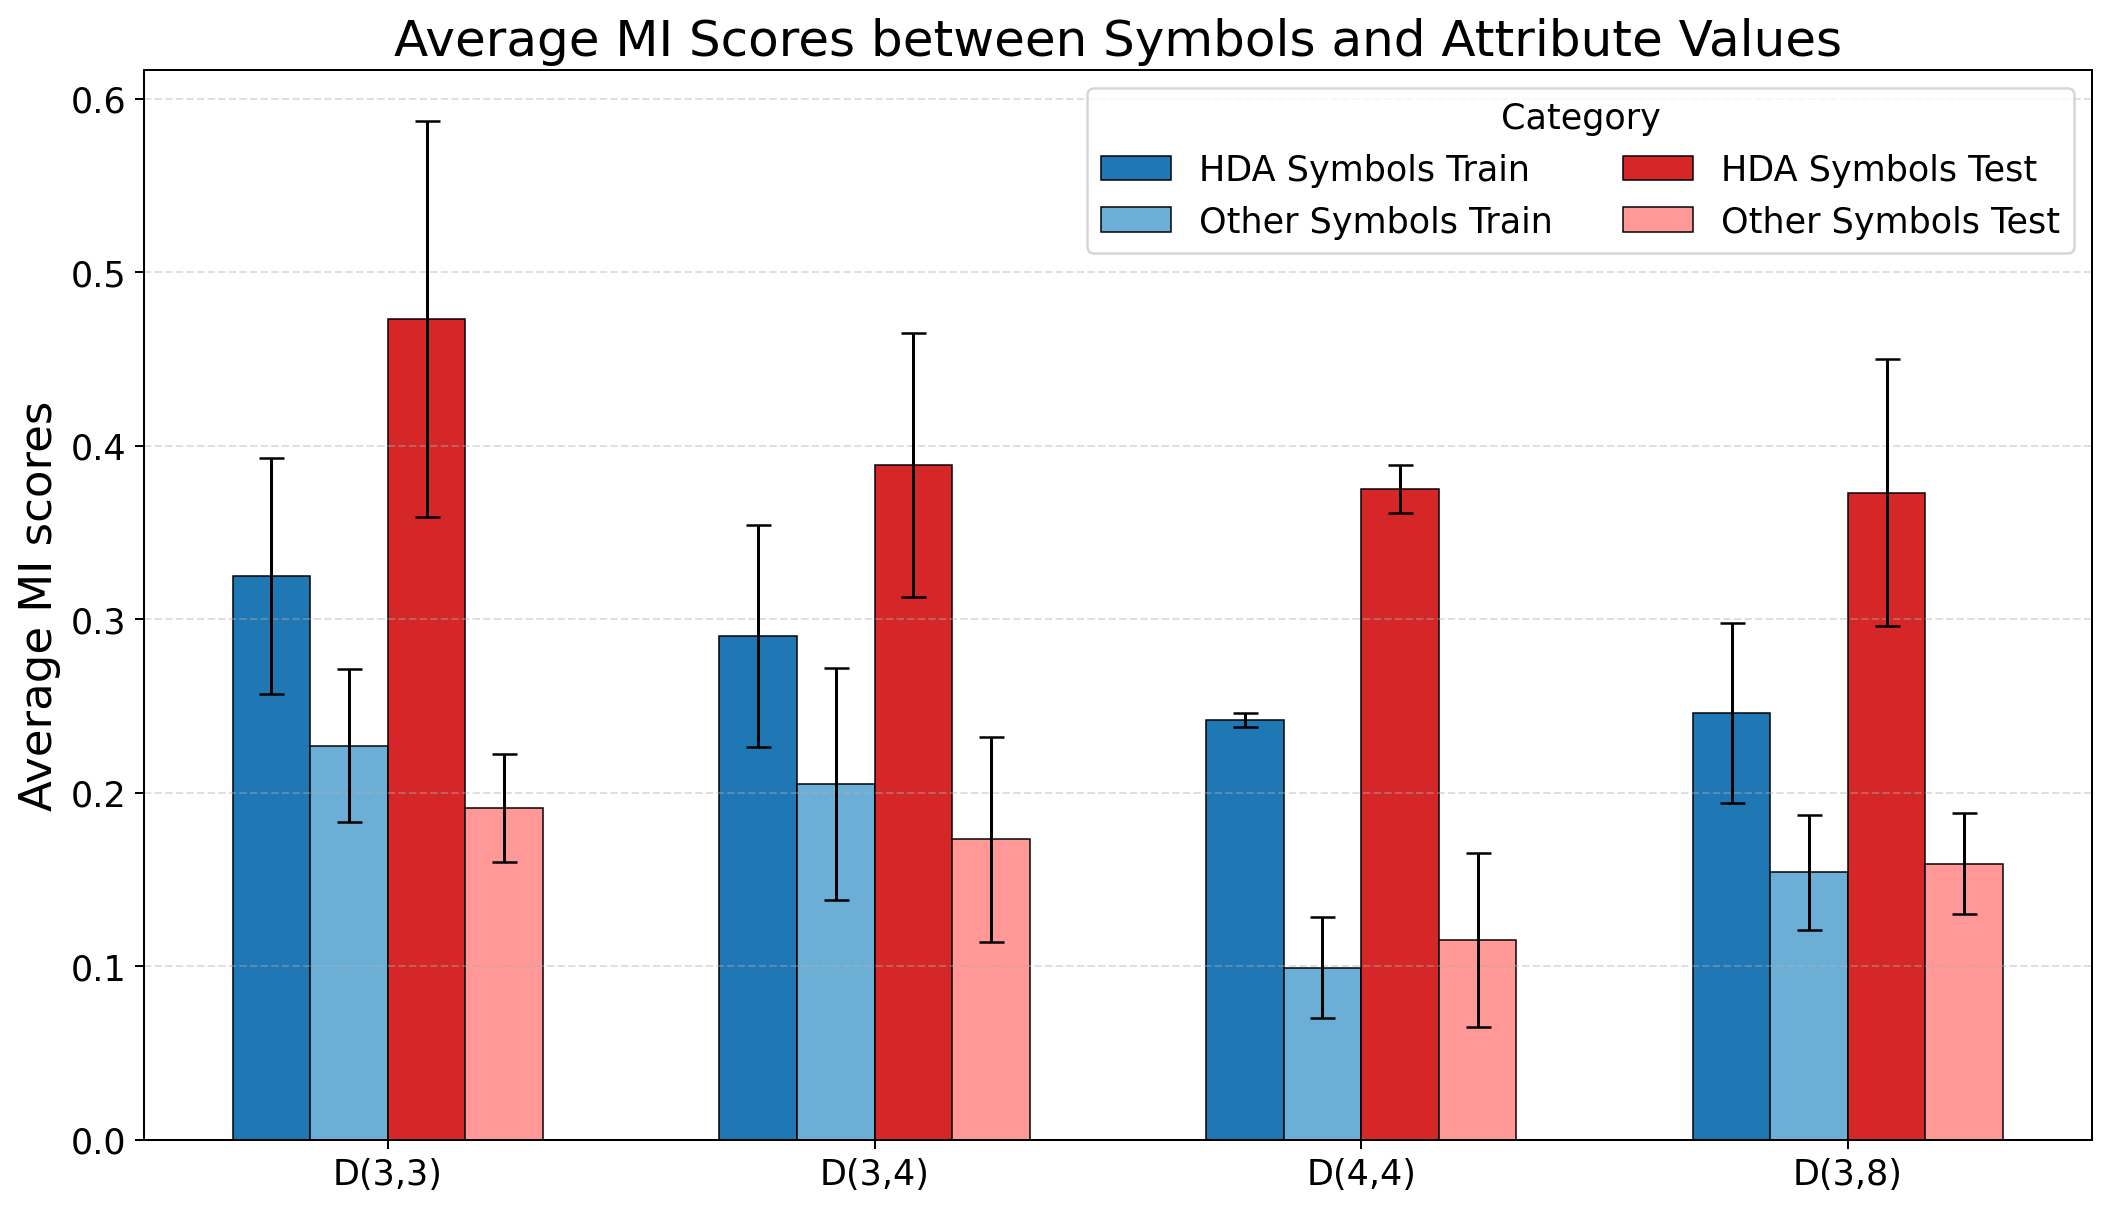

In [ ]:
# plotting average MI scores of HDA symbols vs other symbols
import matplotlib.pyplot as plt
import numpy as np

# mean and std values for MI scores of HDA symbols and other symbols (they were computed separately)
data = {
    "D(3,3)": {
        "HDA Symbols Train":   (0.325, 0.068),
        "Other Symbols Train": (0.227, 0.044),
        "HDA Symbols Test":    (0.473, 0.114),
        "Other Symbols Test":  (0.191, 0.031),  
    },
    "D(3,4)": {
        "HDA Symbols Train":   (0.290, 0.064),
        "Other Symbols Train": (0.205, 0.067),
        "HDA Symbols Test":    (0.389, 0.076),
        "Other Symbols Test":  (0.173, 0.059),
    },
    "D(4,4)": {
        "HDA Symbols Train":   (0.242, 0.004),
        "Other Symbols Train": (0.099, 0.029),
        "HDA Symbols Test":    (0.375, 0.014),
        "Other Symbols Test":  (0.115, 0.050),
    },
    "D(3,8)": {
        "HDA Symbols Train":   (0.246, 0.052),
        "Other Symbols Train": (0.154, 0.033),
        "HDA Symbols Test":    (0.373, 0.077),
        "Other Symbols Test":  (0.159, 0.029),
    },
}
# order of dataset groups and categories (bar order inside each group)
groups = ["D(3,3)", "D(3,4)", "D(4,4)", "D(3,8)"]
categories = ["HDA Symbols Train", "Other Symbols Train", "HDA Symbols Test", "Other Symbols Test"]


plt.rcParams.update({
    "font.size": 16,            # base font
    "axes.titlesize": 20,       # plot title
    "axes.labelsize": 18,       # axis labels
    "xtick.labelsize": 14,      # x tick labels
    "ytick.labelsize": 14,      # y tick labels
    "legend.fontsize": 14,      # legend text
    "legend.title_fontsize": 14 # legend title
})


color_map = {
    "HDA Symbols Train":    "#1f77b4",  # deep blue
    "Other Symbols Train":     "#6baed6",  # lighter blue
    "HDA Symbols Test": "#d62728",  # deep red
    "Other Symbols Test":  "#ff9896",  # lighter red
}


n_groups = len(groups)
n_series = len(categories)
bar_width = 0.22
group_spacing = 0.5  


x_base = np.arange(n_groups) * (n_series * bar_width + group_spacing)


fig = plt.figure(figsize=(12, 7), dpi=180)

for s, cat in enumerate(categories):
    x = x_base + s * bar_width
    means = [data[g][cat][0] for g in groups]
    stds  = [data[g][cat][1] for g in groups]
    plt.bar(
        x, means,
        width=bar_width,
        yerr=stds,
        capsize=5,
        ecolor="black",
        error_kw=dict(lw=1.2),
        label=cat,
        color=color_map[cat],
        edgecolor="black",
        linewidth=0.6,
    )


xticks = x_base + (n_series - 1) * bar_width / 2
plt.xticks(xticks, groups)

plt.ylabel("Average MI scores")
plt.title("Average MI Scores between Symbols and Attribute Values")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Category", ncol=2, frameon=True, loc="upper right")
plt.tight_layout()


plt.show()